In [1]:
import os
import sys
from typing import List, Tuple

ROOT = os.path.abspath(os.path.join('..', '..'))
if ROOT not in sys.path:
    sys.path.append(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# # Make repository root importable when run from experiments/
# ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
# if ROOT not in sys.path:
#     sys.path.append(ROOT)

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

from disco.explain.disco_algorithm import DiscoRunner
from disco.explain.baselines import BaselineRunner
from disco.explain.pier import compute_pier_metrics
from disco.cli.main import compute_probe_trajectories
from disco.interventions.grids import Grids
from disco.anchors.knn import AnchorSelector
from disco.devices.sklearn_tabular import SklearnDevice
from disco.matching.weights import WeightSolver, MatchInputs

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# =========================
# Configuration
# =========================

ALPHA_GRID = np.linspace(0.1, 1.3, 6)
SEEDS = list(range(5))

N_DEVICES = 10
N_TRAIN_SAMPLES = 400
M_PROBE = 400

THETA0 = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
THETA_POST = np.linspace(0.6, 1.8, 6)

MODE = "s"
BASE_LAMBDA = 0.01

BASE_ANCHOR_K = 50
BASE_ANCHOR_TAU = 0.5

TARGET_IDX = 0
TARGET_CLASS = 0

BETA_THETA_PEER = 0.1

METHOD_ORDER = ["DISCO", "TopK", "AVG", "Ridge"]

In [ ]:
def load_california_data() -> Tuple[np.ndarray, np.ndarray]:
    data = fetch_california_housing()
    X = data.data.astype(np.float32)
    y = data.target.astype(np.float32)

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    return X, y

In [ ]:
def build_device_responses(
    X_real: np.ndarray,
    y_real: np.ndarray,
    theta_vals: np.ndarray,
    alpha_target: float,
    beta_theta_peer: float,
    rng: np.random.RandomState,
    target_idx: int,
    n_devices: int,
    n_train_per_device: int,
) -> Tuple[List[SklearnDevice], np.ndarray, np.ndarray]:
    """
    Construct N devices on real data with non-linear theta effects.

    For each device d and sample i:
        y_d(i) = y_real(i)
                 + beta_lin_d * theta_i
                 + beta_quad_d * theta_i^2
                 + beta_int_d * tanh(theta_i * z1_i)
                 + eps_noise

    Target device has larger beta_lin and beta_quad and beta_int,
    peers have weaker and noisy coefficients.

    The models are MLP regressors to approximate this non-linear mapping.
    """
    n_samples, p0 = X_real.shape
    assert theta_vals.shape[0] == n_samples

    # Augmented features [X_real, theta]
    X_aug = np.concatenate([X_real, theta_vals.reshape(-1, 1)], axis=1)

    # Randomly partition indices into devices
    perm = rng.permutation(n_samples)
    splits = np.array_split(perm, n_devices)

    devices: List[SklearnDevice] = []

    for d_idx, idxs in enumerate(splits):
        if len(idxs) == 0:
            continue

        n_use = min(n_train_per_device, len(idxs))
        train_idx = rng.choice(idxs, size=n_use, replace=False)

        X_d = X_aug[train_idx]
        theta_d = X_d[:, -1]
        y_base = y_real[train_idx]

        z1 = X_d[:, 0]  # use first standardized feature as interaction

        # Device-specific coefficients
        if d_idx == target_idx:
            beta_lin = alpha_target              # main linear sensitivity
            beta_quad = 0.4                      # stronger quadratic term
            beta_int = 0.3                       # stronger interaction
        else:
            beta_lin = beta_theta_peer + rng.normal(0.0, 0.05)
            beta_quad = rng.normal(0.05, 0.02)
            beta_int = rng.normal(0.05, 0.02)

        nonlin_effect = (
            beta_lin * theta_d
            + beta_quad * (theta_d ** 2)
            + beta_int * np.tanh(theta_d * z1)
        )

        eps_noise = rng.normal(0.0, 0.05, size=n_use)

        y_d = y_base + nonlin_effect + eps_noise

        # Non-linear regressor for each device
        local_seed = rng.randint(0, 2**31 - 1)
        model = MLPRegressor(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            max_iter=300,
            random_state=local_seed,
        )
        model.fit(X_d, y_d)

        dev = SklearnDevice(
            id=f"device_{d_idx}",
            model=model,
            task="regression",
            scalarization="identity",
        )
        devices.append(dev)

    # Probe points sampled from whole pool
    probe_idx = rng.choice(n_samples, size=min(M_PROBE, n_samples), replace=False)
    X_probe = X_aug[probe_idx]
    x_star = X_probe[0:1]

    return devices, X_probe, x_star

In [4]:
# =========================
# Interventions
# =========================

class ThetaSet:
    """
    Intervention that directly sets the last feature to the given theta.
    This assumes the augmented feature is [X_real, theta] and theta is last.
    """
    def __init__(self, feat_idx: int, name: str = "theta_direction"):
        self.feat_idx = feat_idx
        self.name = name

    def apply(self, X: np.ndarray, theta: float) -> np.ndarray:
        X_int = np.array(X, copy=True)
        X_int[:, self.feat_idx] = theta
        return X_int


def make_interventions(p_aug: int):
    theta_feat_idx = p_aug - 1
    return [ThetaSet(feat_idx=theta_feat_idx, name="theta_direction")]


# =========================
# Diagnostics
# =========================

def effective_sample_size(weights: np.ndarray, eps: float = 1e-12) -> float:
    w = np.asarray(weights, dtype=float)
    w = np.maximum(w, 0.0)
    s = w.sum()
    if s <= eps:
        return 0.0
    w = w / s
    return float(1.0 / np.sum(w ** 2))


def weight_entropy(weights: np.ndarray, eps: float = 1e-12) -> float:
    w = np.asarray(weights, dtype=float)
    w = np.maximum(w, 0.0)
    s = w.sum()
    if s <= eps:
        return 0.0
    w = w / s
    mask = w > 0
    return float(-np.sum(w[mask] * np.log(w[mask])))

Loaded California housing data: 20640 samples, 8 features.
Running alpha=0.10, seed=0
Running alpha=0.10, seed=1
Running alpha=0.10, seed=2
Running alpha=0.10, seed=3
Running alpha=0.10, seed=4
Running alpha=0.34, seed=0
Running alpha=0.34, seed=1
Running alpha=0.34, seed=2
Running alpha=0.34, seed=3
Running alpha=0.34, seed=4
Running alpha=0.58, seed=0
Running alpha=0.58, seed=1
Running alpha=0.58, seed=2
Running alpha=0.58, seed=3
Running alpha=0.58, seed=4
Running alpha=0.82, seed=0
Running alpha=0.82, seed=1
Running alpha=0.82, seed=2
Running alpha=0.82, seed=3
Running alpha=0.82, seed=4
Running alpha=1.06, seed=0
Running alpha=1.06, seed=1
Running alpha=1.06, seed=2
Running alpha=1.06, seed=3
Running alpha=1.06, seed=4
Running alpha=1.30, seed=0
Running alpha=1.30, seed=1
Running alpha=1.30, seed=2
Running alpha=1.30, seed=3
Running alpha=1.30, seed=4


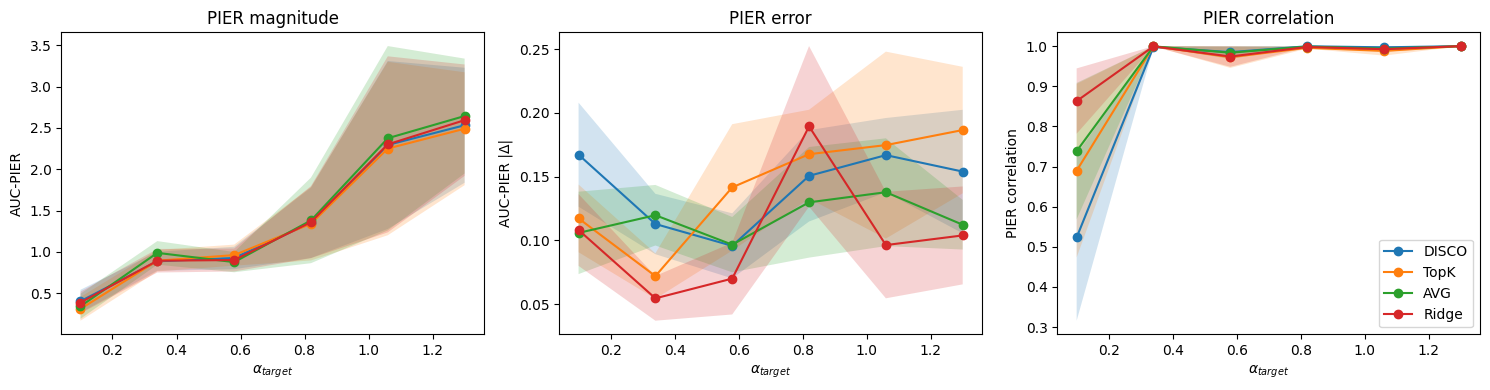

In [5]:
X_real, y_real = load_california_data()
n_samples, p0 = X_real.shape
print(f"Loaded California housing data: {n_samples} samples, {p0} features.")

records = []

disco_runner = DiscoRunner(mode=MODE, lam=BASE_LAMBDA)
baseline_runner = BaselineRunner()
weight_solver = WeightSolver()

for alpha in ALPHA_GRID:
    for rep_seed in SEEDS:
        print(f"Running alpha={alpha:.2f}, seed={rep_seed}")
        seed = int(rep_seed + round(alpha * 100))
        rng = np.random.RandomState(seed)

        # Sample theta values for training world
        theta_grid_train = np.concatenate([THETA0, THETA_POST])
        theta_vals = rng.choice(theta_grid_train, size=n_samples)

        # Build devices with non-linear theta responses
        devices, X_probe, x_star = build_device_responses(
            X_real=X_real,
            y_real=y_real,
            theta_vals=theta_vals,
            alpha_target=alpha,
            beta_theta_peer=BETA_THETA_PEER,
            rng=rng,
            target_idx=TARGET_IDX,
            n_devices=N_DEVICES,
            n_train_per_device=N_TRAIN_SAMPLES,
        )

        p_aug = X_probe.shape[1]
        interventions = make_interventions(p_aug)
        grids = Grids(theta0=THETA0, theta=THETA_POST)

        # Probe trajectories for all devices in pre-window
        trajectories = compute_probe_trajectories(
            devices=devices,
            X_probe=X_probe,
            interventions=interventions,
            theta0=THETA0,
            dp_noise_std=0.0,
            seed=seed,
            target_class=TARGET_CLASS,
        )

        # Anchor selection for this x_star
        anchor_selector = AnchorSelector(
            K=min(BASE_ANCHOR_K, len(X_probe)),
            tau=BASE_ANCHOR_TAU,
        )
        anchor_sel = anchor_selector.select(X_probe, x_star)

        peer_ids = [d.id for i, d in enumerate(devices) if i != TARGET_IDX]

        for intervention in interventions:
            # 1) DISCO
            disco_out = disco_runner.run(
                devices=devices,
                target_idx=TARGET_IDX,
                x_star=x_star,
                X_probe=X_probe,
                trajectories=trajectories,
                grids=grids,
                intervention=intervention,
                target_class=TARGET_CLASS,
                mode=MODE,
                lam=BASE_LAMBDA,
                anchor_selector=anchor_selector,
                weight_solver=weight_solver,
                anchor_space="response",
            )
            weights_disco = disco_out.weights
            tau_disco = disco_out.te_output.tau

            # 2) AVG baseline
            avg_out = baseline_runner.baseline_avg(
                devices=devices,
                x_star=x_star,
                grids=grids,
                intervention=intervention,
                target_idx=TARGET_IDX,
                target_class=TARGET_CLASS,
            )
            tau_avg = avg_out.tau

            # 3) TopK baseline
            topk_out = baseline_runner.baseline_topk_avg(
                devices=devices,
                trajectories=trajectories,
                anchor_sel=anchor_sel,
                theta0=THETA0,
                x_star=x_star,
                grids=grids,
                intervention=intervention,
                target_idx=TARGET_IDX,
                Kp=3,
                target_class=TARGET_CLASS,
            )
            tau_topk = topk_out.tau

            # 4) Unconstrained Ridge baseline
            ridge_out = baseline_runner.baseline_unconstrained_ridge(
                devices=devices,
                trajectories=trajectories,
                anchor_sel=anchor_sel,
                theta0=THETA0,
                x_star=x_star,
                grids=grids,
                intervention=intervention,
                target_idx=TARGET_IDX,
                lam=BASE_LAMBDA,
                target_class=TARGET_CLASS,
            )
            tau_ridge = ridge_out.tau

            # 5) Oracle synthetic control: fit weights on pre-window probes
            target_device = devices[TARGET_IDX]
            target_key = (target_device.id, intervention.name)
            target_pre = trajectories[target_key]  # [m, len(THETA0)]

            peer_trajs = []
            for d in devices:
                if d.id == target_device.id:
                    continue
                key = (d.id, intervention.name)
                peer_traj = trajectories[key]
                peer_trajs.append(peer_traj)
            peer_trajs = np.stack(peer_trajs, axis=-1)  # [m, q0, n_peers]

            Y_t = target_pre.reshape(-1)
            Y_p = peer_trajs.reshape(-1, peer_trajs.shape[-1])

            match_inputs = MatchInputs(y_t=Y_t, X_peers=Y_p, lam=BASE_LAMBDA)
            match_result = weight_solver.solve(match_inputs)
            w_star = np.asarray(match_result.w, dtype=float)
            if w_star.sum() > 0:
                w_star = w_star / w_star.sum()

            def tau_oracle(theta_val: float) -> float:
                X_cf = intervention.apply(x_star, theta_val)
                raw_t = target_device.predict_raw(X_cf)
                y_t = target_device.g(raw_t, TARGET_CLASS)[0]
                peer_preds = []
                for d in devices:
                    if d.id == target_device.id:
                        continue
                    raw_p = d.predict_raw(X_cf)
                    peer_preds.append(d.g(raw_p, TARGET_CLASS)[0])
                peer_preds = np.asarray(peer_preds, dtype=float)
                return float(y_t - np.dot(w_star, peer_preds))

            tau_oracle_vals = np.array([tau_oracle(t) for t in THETA_POST])

            # Use Oracle TE curve as pseudo ground truth
            tau_true = tau_oracle_vals.copy()

            method_curves = {
                "DISCO": (weights_disco, tau_disco),
                "TopK": (topk_out.meta.get("weights", None), tau_topk),
                "AVG": (np.ones(len(peer_ids)) / len(peer_ids), tau_avg),
                "Ridge": (ridge_out.meta.get("weights", None), tau_ridge),
                "Oracle": (w_star, tau_oracle_vals),
            }

            for method, (weights, tau_hat) in method_curves.items():
                if weights is None:
                    weights = np.ones(len(peer_ids)) / len(peer_ids)

                tau_hat_arr = np.asarray(tau_hat, dtype=float)
                tau_true_arr = np.asarray(tau_true, dtype=float)

                pier_metrics = compute_pier_metrics(
                    tau_hat_arr,
                    tau_true_arr,
                    THETA_POST,
                    None,
                )

                ess = effective_sample_size(weights)
                ent = weight_entropy(weights)
                auc_abs = float(np.trapz(np.abs(tau_hat_arr), THETA_POST))

                records.append(
                    {
                        "alpha_target": float(alpha),
                        "seed": int(rep_seed),
                        "method": method,
                        "intervention": intervention.name,
                        "pier_auc_abs_diff": pier_metrics["pier_auc_abs_diff"],
                        "pier_nrmse": pier_metrics["pier_nrmse"],
                        "pier_corr": pier_metrics["pier_corr"],
                        "auc_abs": auc_abs,
                        "ess": ess,
                        "entropy": ent,
                    }
                )

df = pd.DataFrame(records)

# Summary and 3-panel figure
summary = (
    df.groupby(["method", "alpha_target"])
    .agg(
        mean_auc=("auc_abs", "mean"),
        std_auc=("auc_abs", "std"),
        mean_delta=("pier_auc_abs_diff", "mean"),
        std_delta=("pier_auc_abs_diff", "std"),
        mean_corr=("pier_corr", "mean"),
        std_corr=("pier_corr", "std"),
        count=("auc_abs", "count"),
    )
    .reset_index()
)

summary["sem_auc"] = summary["std_auc"] / np.sqrt(summary["count"].clip(lower=1))
summary["sem_delta"] = summary["std_delta"] / np.sqrt(summary["count"].clip(lower=1))
summary["sem_corr"] = summary["std_corr"] / np.sqrt(summary["count"].clip(lower=1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

metric_specs = [
    ("mean_auc", "sem_auc", "AUC-PIER", "PIER magnitude"),
    ("mean_delta", "sem_delta", "AUC-PIER |Δ|", "PIER error"),
    ("mean_corr", "sem_corr", "PIER correlation", "PIER correlation"),
]

for ax, (mean_key, sem_key, y_label, title) in zip(axes, metric_specs):
    for method in METHOD_ORDER:
        data = summary[summary["method"] == method].sort_values("alpha_target")
        if data.empty:
            continue
        x = data["alpha_target"].values
        y = data[mean_key].values
        yerr = data[sem_key].fillna(0.0).values
        ax.plot(x, y, marker="o", label=method)
        ax.fill_between(x, y - yerr, y + yerr, alpha=0.2)
    ax.set_xlabel(r"$\alpha_{target}$")
    ax.set_ylabel(y_label)
    ax.set_title(title)

axes[-1].legend(loc="best")
fig.tight_layout()
plt.show()